<a href="https://colab.research.google.com/github/bigirimanainnocent12/Spark/blob/main/PYSPARK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Description de la base de données***

Cet ensemble de données recense les incidents criminels signalés (à l'exception des homicides pour lesquels des données existent pour chaque victime) survenus dans la ville de Chicago de 2001 à 14/11/2025, moins les sept derniers jours. Les données proviennent du système CLEAR (Citizen Law Enforcement Analysis and Reporting) du département de police de Chicago. Afin de protéger la vie privée des victimes, les adresses sont affichées au niveau du pâté de maisons uniquement et les lieux précis ne sont pas identifiés. Pour toute question concernant cet ensemble de données, veuillez contacter la Division de l'analyse et du traitement des données du département de police de Chicago à l'adresse DFA@ChicagoPolice.org.

[
Lien pour télécharger les données](https://data.cityofchicago.org/Public-Safety/Crimes-2001-to-Present/ijzp-q8t2/about_data)

In [250]:
!pip install pyspark
!pip install findspark

In [251]:
from pyspark.sql import SparkSession
spark=SparkSession.builder.appName("Analyse des crimes dans la ville de Chicago").getOrCreate()

# **Importation des données et affichage de 20 premières lignes**

In [252]:
df=spark.read.csv("/content/drive/MyDrive/BOURSE DATA SCIENCE/crimes.csv",header=True,inferSchema=True)
df.show(5)

+--------+-----------+--------------------+--------------------+----+------------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+--------------------+------------+-------------+--------------------+
|      ID|Case Number|                Date|               Block|IUCR|      Primary Type|         Description|Location Description|Arrest|Domestic|Beat|District|Ward|Community Area|FBI Code|X Coordinate|Y Coordinate|Year|          Updated On|    Latitude|    Longitude|            Location|
+--------+-----------+--------------------+--------------------+----+------------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+--------------------+------------+-------------+--------------------+
|14047576|   JJ512272|12/05/2025 12:00:...|   053XX N LYNCH AVE|1310|   CRIMINAL DAMAGE|         TO PROPERTY|           RESIDENCE|

# ***chargement des types des variables***

In [253]:
from pyspark.sql.functions import col, to_timestamp

df = df.withColumn("Date", to_timestamp(col("Date"), "MM/dd/yyyy hh:mm:ss a")) \
       .withColumn("Latitude", col("Latitude").cast("float")) \
       .withColumn("Longitude", col("Longitude").cast("float")) \
       .withColumn("Updated On", to_timestamp(col("Updated On"), "MM/dd/yyyy hh:mm:ss a"))

# ***Type de variable pour chaque colonne***

In [254]:
df.dtypes

[('ID', 'int'),
 ('Case Number', 'string'),
 ('Date', 'timestamp'),
 ('Block', 'string'),
 ('IUCR', 'string'),
 ('Primary Type', 'string'),
 ('Description', 'string'),
 ('Location Description', 'string'),
 ('Arrest', 'boolean'),
 ('Domestic', 'boolean'),
 ('Beat', 'int'),
 ('District', 'int'),
 ('Ward', 'int'),
 ('Community Area', 'int'),
 ('FBI Code', 'string'),
 ('X Coordinate', 'int'),
 ('Y Coordinate', 'int'),
 ('Year', 'int'),
 ('Updated On', 'timestamp'),
 ('Latitude', 'float'),
 ('Longitude', 'float'),
 ('Location', 'string')]

# ***Nombre de valeurs nulles par colonne***

In [255]:
from pyspark.sql.functions import col,sum
df.select([sum(col(c).isNull().cast('int').alias(c)) for c in df.columns]).show()

+------------------------------------+--------------------------------------------------------+----------------------------------------+------------------------------------------+----------------------------------------+----------------------------------------------------------+------------------------------------------------------+--------------------------------------------------------------------------+--------------------------------------------+------------------------------------------------+----------------------------------------+------------------------------------------------+----------------------------------------+--------------------------------------------------------------+--------------------------------------------------+----------------------------------------------------------+----------------------------------------------------------+----------------------------------------+------------------------------------------------------+--------------------------------------

# ***CRIMINAL SEXUAL ASSAULT==CRIM SEXUAL ASSAULT***

In [256]:
from pyspark.sql.functions import when, col
df = df.withColumn(
    "Primary Type",
    when(col("Primary Type") =="CRIM SEXUAL ASSAULT","CRIMINAL SEXUAL ASSAULT")
    .otherwise(col("Primary Type"))
)

# ***Création des quelques colonnes importantes***

In [257]:
from pyspark.sql.functions import col,dayofmonth,month,weekday,when
df = df.withColumn("Jour du mois", dayofmonth(col("Date")))\
       .withColumn("mois de l'incident",month(col("Date")))\
       .withColumn("Jour de la semaine",weekday(col("Date")))\
       .withColumn("Week_end",when(col("Jour de la semaine").isin(0,4),0).otherwise(1))

In [258]:
def mois(mois):
  if mois==1:
    return "Janvier"
  elif mois==2:
    return "Février"
  elif mois==3:
    return 'Mars'
  elif mois==4:
    return 'Avril'
  elif mois==5:
    return 'Mai'
  elif mois==6:
    return 'Juin'
  if mois==7:
    return "Juillet"
  elif mois==8:
    return "Août"
  elif mois==9:
    return 'Septembre'
  elif mois==10:
    return 'Octobre'
  elif mois==11:
    return 'Novembre'
  else:
    return 'Décembre'

def jourdelasemaine(jour):
  if jour==0:
    return "Lundi"
  if jour==1:
    return "Mardi"
  if jour==2:
    return "Mecredi"
  if jour==3:
    return "Jeudi"
  if jour==4:
    return "Vendredi"
  if jour==5:
    return "Samedi"
  if jour==6:
    return "Dimanche"

In [259]:
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType
mois_udf=udf(mois,StringType())
jourdelasemaine_udf=udf(jourdelasemaine,StringType())
df=df.withColumn("mois de l'incident",mois_udf(col("mois de l'incident")))
df=df.withColumn("Jour de la semaine",jourdelasemaine_udf(col("Jour de la semaine")))

# ***Taux d'arrestation***

In [260]:
print(f"Le taux d'arrestation à chicago est de {(df.filter(col('Arrest')=="true").count()/df.count())*100}%")

Le taux d'arrestation à chicago est de 25.189348712305808%


# ***Taux d'arrestation par an***

In [261]:
from pyspark.sql.functions import col

arrestation_an = df.filter(col("Arrest") == True).groupBy("Year").count().withColumnRenamed("count", "Arrestations")
nombre_incident_an = df.groupBy("Year").count().withColumnRenamed("count","Nombre d'incident")
resultat = arrestation_an.join(nombre_incident_an, on="Year", how="inner")
resultat=(resultat).toPandas()
resultat["Taux arrestation"]=(resultat["Arrestations"]/resultat["Nombre d'incident"])*100
resultat

,Year,Arrestations,Nombre d'incident,Taux arrestation
0,2025,34987,219935,15.907882
1,2024,35744,258852,13.808663
2,2023,32154,263201,12.216519
3,2022,28226,239956,11.762990
4,2019,56299,261679,21.514527
5,2020,34196,212674,16.079069
6,2021,26648,209621,12.712467
7,2018,53919,269128,20.034705
8,2016,53072,269946,19.660228
9,2017,52696,269276,19.569512


# ***Evolution du taux d'arrestation par an***

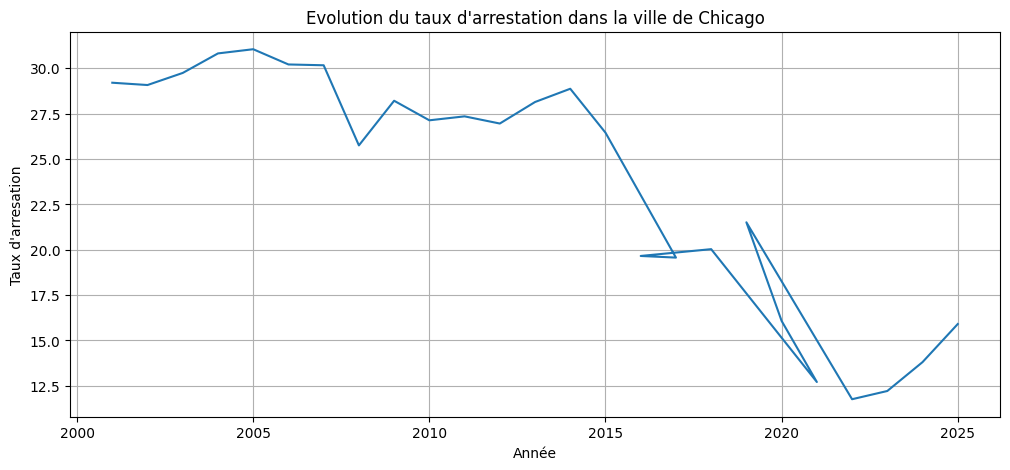

In [262]:
plt.figure(figsize=(12,5))
plt.plot(resultat["Year"],resultat["Taux arrestation"])
plt.title("Evolution du taux d'arrestation dans la ville de Chicago")
plt.ylabel("Taux d'arresation")
plt.xlabel("Année")
plt.grid(True)
plt.show()

# ***Taux d’arrestation par jour***

In [240]:
from pyspark.sql.functions import col, lit
Nombre_incident_jour = df.groupBy("Jour de la semaine").count().withColumnRenamed("count","Nombre_incident_jour")
nombre_arrestation_jour = df.filter(col("Arrest") == lit("true")).groupBy("Jour de la semaine").count().withColumnRenamed("count","nombre_arrestation_jour")
jointure = Nombre_incident_jour.join(nombre_arrestation_jour, on="Jour de la semaine", how="left")
jointure = jointure.toPandas()
jointure["taux d'arrestation par jour"]=(jointure["nombre_arrestation_jour"]/jointure["Nombre_incident_jour"])*100
jointure

,Jour de la semaine,Nombre_incident_jour,nombre_arrestation_jour,taux d'arrestation par jour
0,Dimanche,1154974,279945,24.238208
1,Vendredi,1268376,318854,25.138760
2,Mecredi,1215210,315754,25.983493
3,Lundi,1196723,291283,24.340052
4,Samedi,1212901,301302,24.841434
5,Mardi,1207612,312282,25.859465
6,Jeudi,1203200,311346,25.876496


# ***Nombre d'incident vs nombre d'arrestation***

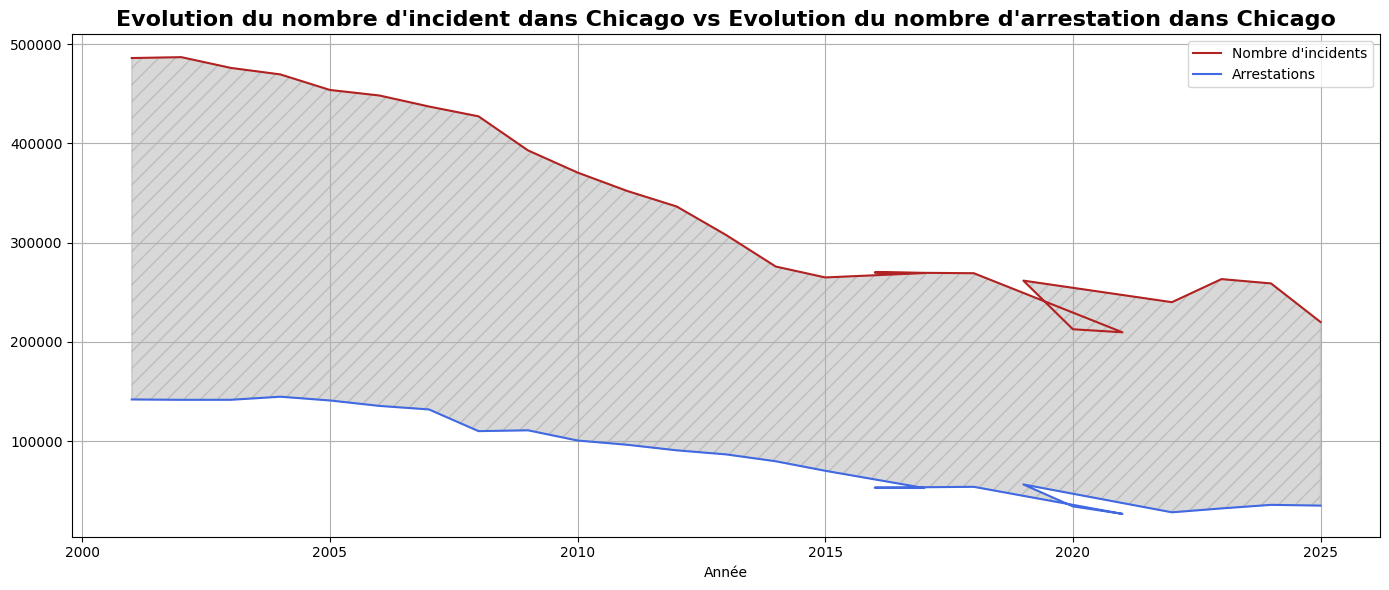

In [242]:
import matplotlib.pyplot as plt

annees = resultat["Year"]
incidents = resultat["Nombre d'incident"]
arrestations = resultat["Arrestations"]

plt.figure(figsize=(14, 6))

plt.plot(annees, incidents, label="Nombre d'incidents", color="firebrick")
plt.plot(annees, arrestations, label="Arrestations", color="royalblue")


plt.fill_between(annees, incidents, arrestations, color="gray", alpha=0.3, hatch="//")

plt.title("Evolution du nombre d'incident dans Chicago vs Evolution du nombre d'arrestation dans Chicago", fontsize=16, fontweight="bold")
plt.xlabel("Année")
plt.ylabel("")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ***Nombre d'incident par mois***

In [243]:
df.groupBy("mois de l'incident").count().show()

+------------------+------+
|mois de l'incident| count|
+------------------+------+
|          Décembre|622885|
|             Avril|688330|
|              Mars|691398|
|           Juillet|788167|
|         Septembre|734303|
|           Octobre|742819|
|           Janvier|661356|
|              Août|779142|
|               Mai|748874|
|           Février|584479|
|          Novembre|668223|
|              Juin|749020|
+------------------+------+



# ***Nombre d'incident par mois selon arrestation ou non***

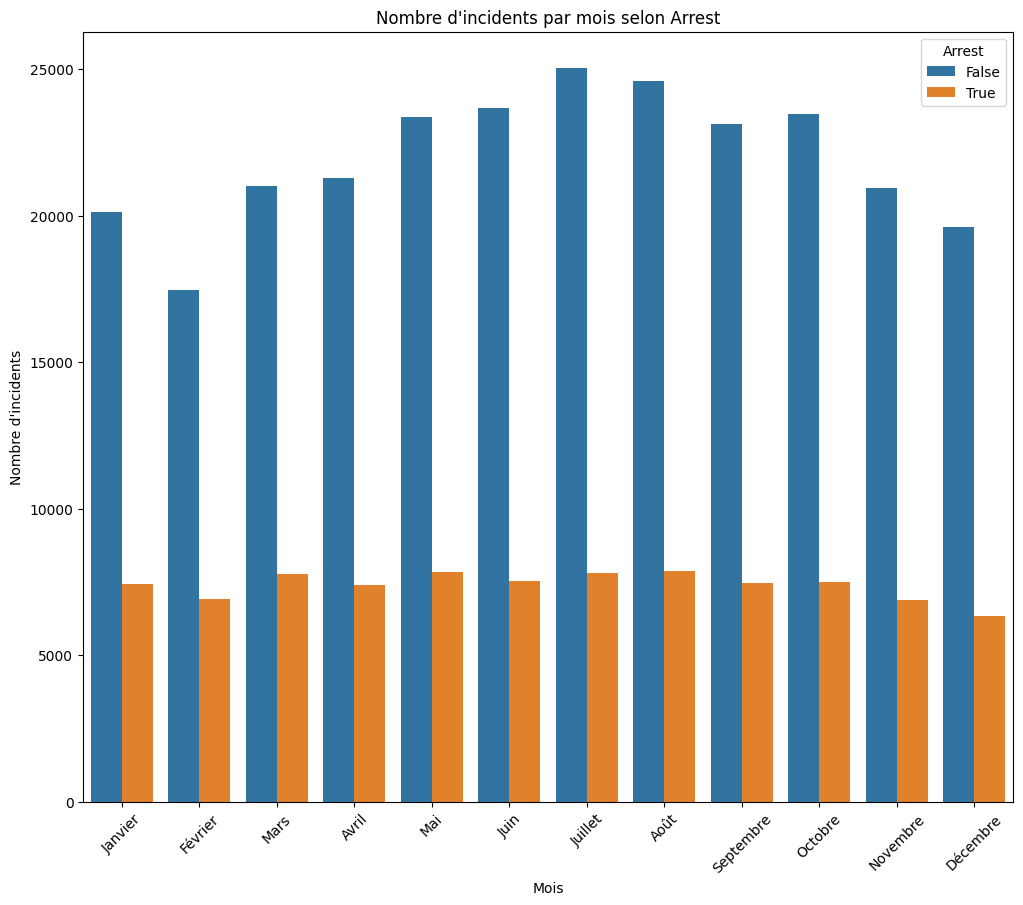

In [244]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

mois = (df.groupBy(["mois de l'incident","Arrest"])
          .count()
          .orderBy("mois de l'incident", ascending=True)
          ).toPandas()
mois["count"]=mois["count"]/len(mois["count"])

ordre_mois = ["Janvier","Février","Mars","Avril","Mai","Juin",
              "Juillet","Août","Septembre","Octobre","Novembre","Décembre"]

mois["mois de l'incident"] = pd.Categorical(
    mois["mois de l'incident"],
    categories=ordre_mois,
    ordered=True
)

plt.figure(figsize=(12,10))
sns.barplot(x="mois de l'incident", y="count", hue="Arrest", data=mois)
plt.xlabel("Mois")
plt.ylabel("Nombre d'incidents")
plt.title("Nombre d'incidents par mois selon Arrest")
plt.xticks(rotation=45)
plt.show()

# ***Répartition des incidents par caractère domestique et arrestation***

In [245]:
df.groupBy(["Domestic","Arrest"]).count().show()

+--------+------+-------+
|Domestic|Arrest|  count|
+--------+------+-------+
|    true| false|1179716|
|    true|  true| 280986|
|   false| false|5148514|
|   false|  true|1849780|
+--------+------+-------+



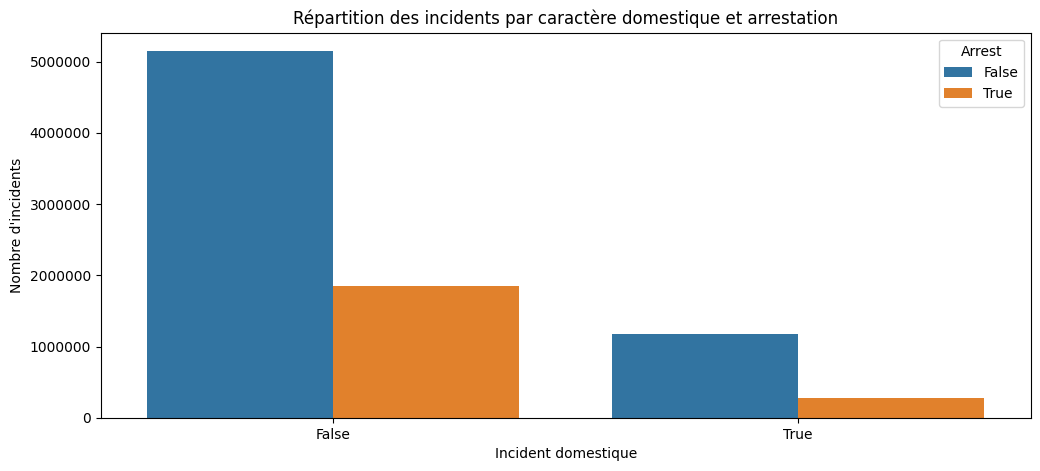

In [246]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df_group = df.groupBy(["Domestic","Arrest"]).count().toPandas()

plt.figure(figsize=(12,5))
sns.barplot(x="Domestic", y="count", hue="Arrest", data=df_group)

plt.title("Répartition des incidents par caractère domestique et arrestation")
plt.xlabel("Incident domestique")
plt.ylabel("Nombre d'incidents")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: int(x)))
plt.show()

In [247]:
df.groupBy(["Year","Primary Type"]).count().withColumnRenamed("count","Nombre d'incident").show()

+----+--------------------+-----------------+
|Year|        Primary Type|Nombre d'incident|
+----+--------------------+-----------------+
|2025|CONCEALED CARRY L...|              257|
|2024|            BURGLARY|             8428|
|2025|INTERFERENCE WITH...|              860|
|2024|  DECEPTIVE PRACTICE|            16153|
|2025|             ROBBERY|             5495|
|2024|INTERFERENCE WITH...|              691|
|2025|   CRIMINAL TRESPASS|             4919|
|2024|        INTIMIDATION|              164|
|2024| MOTOR VEHICLE THEFT|            21713|
|2024|           NARCOTICS|             5981|
|2024|OFFENSE INVOLVING...|             1680|
|2024|        PROSTITUTION|              307|
|2025|        PROSTITUTION|              188|
|2025|          KIDNAPPING|               80|
|2024|             ROBBERY|             9116|
|2025|            STALKING|              532|
|2024|          KIDNAPPING|               96|
|2024|   HUMAN TRAFFICKING|               19|
|2024|CONCEALED CARRY L...|       